# Exercise 3: Numerical Instability and Stability Analysis

## Learning Objectives

By completing this exercise, you will:
- Recognize symptoms of numerical instability
- Understand the relationship between finite difference direction and wave propagation
- Investigate the CFL stability condition empirically
- Implement backward and centered finite difference schemes
- (Optional) Solve the nonlinear Burgers' equation

---

## Introduction

Numerical instability is one of the critical problems in computational physics. In this exercise, we will see how **violent** numerical instabilities can be and learn to recognize their symptoms.

In [11]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import importlib

import nm_lib.nm_ex.nm_lib_ex_3 as nm3
importlib.reload(nm3)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
torch.set_default_dtype(dtype)

def lib_ddx_torch(ddx_fun, u, dx):
    xx = (torch.arange(u.numel(), device=device, dtype=dtype) * dx).detach().cpu().numpy()
    uu = u.detach().cpu().numpy()
    du = ddx_fun(xx, uu)
    du = np.nan_to_num(du, nan=0.0)
    return torch.tensor(du, device=device, dtype=dtype)



#Problem 3 The Numerical Instability and Stability Analysis

# Try to use Torch (GPU) if available 
try:
    import torch
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dtype = torch.float64
torch.set_default_dtype(dtype)

USE_TORCH = TORCH_AVAILABLE  # True: torch and False: numpy

---

## Part 1: Numerical Instability — Violent Development

### Task 1.1: Trigger Instability by Changing Sign of $a$

Repeat the numerical simulation from [Exercise 2b](https://github.com/AST-Course/AST5110/blob/main/notebooks/ex_2b.ipynb), but now with $a = +1$ (instead of $a = -1$).

**Steps:**
1. Use a moderate number of intervals (e.g., 128)
2. Observe what happens
3. Count after how many timesteps instability becomes evident

**Follow-up:** Repeat with 1024 points (and other powers of 2). Is the experiment stable now? After how many timesteps does instability appear?

### Task 1.2: Implement Backward Finite Differences

For $a = 1$, use **backward** finite differencing for the spatial derivative:

$$\left(\frac{\partial u}{\partial x}\right)_{x=x_i} \rightarrow \frac{u_i-u_{i-1}}{\Delta x}  \tag{1}$$

**Implementation:** Fill in the function `deriv_bck` in [`nm_lib`](https://github.com/AST-Course/nm_lib/tree/master/nm_lib/nm_ex/nm_lib_ex_3.py). Use the `lambda` function `ddx` and select the proper limits for `bnd_limits`.

> **Important:** Take care to also change the implementation of the boundary condition!

**Question:** Does the unstable character of the code change with backward differencing?

For $a = -1$, use **backward** finite differencing for the spatial derivative, Is unstable?


N=128 (points=129), instability step = 13
N=1024 (points=1025), instability step = 35


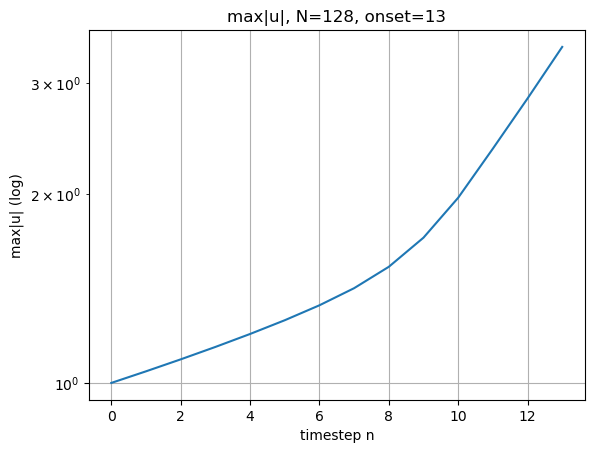

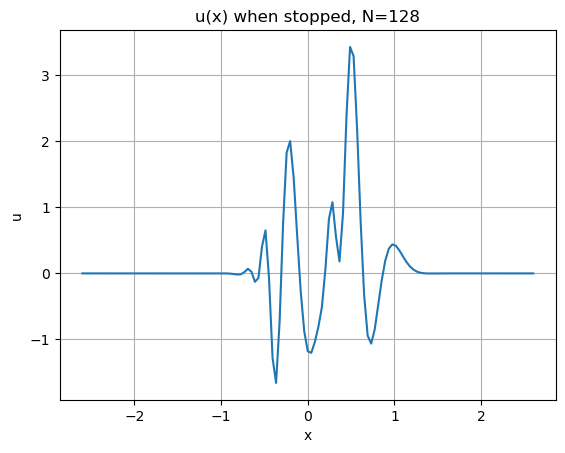

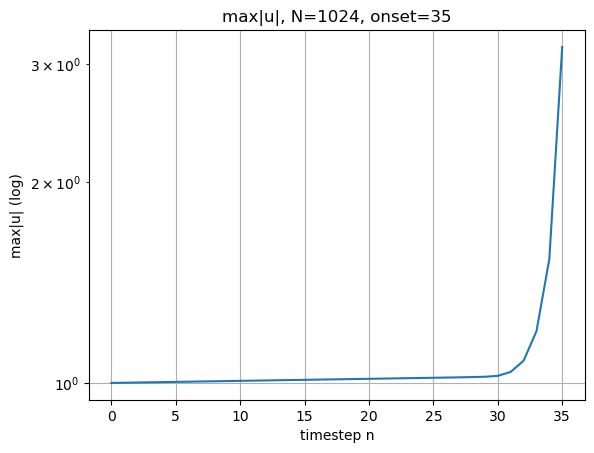

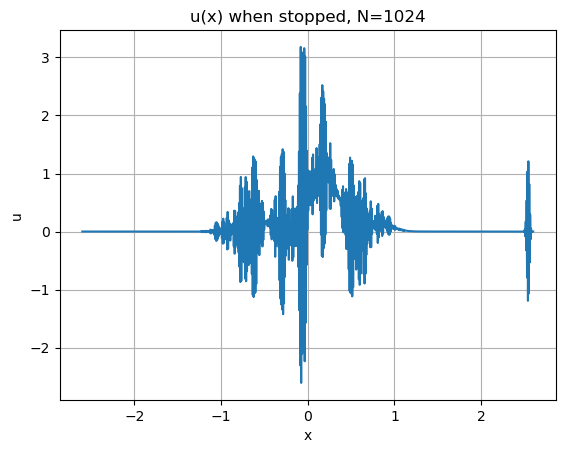

Backward difference, a=+1, onset = None


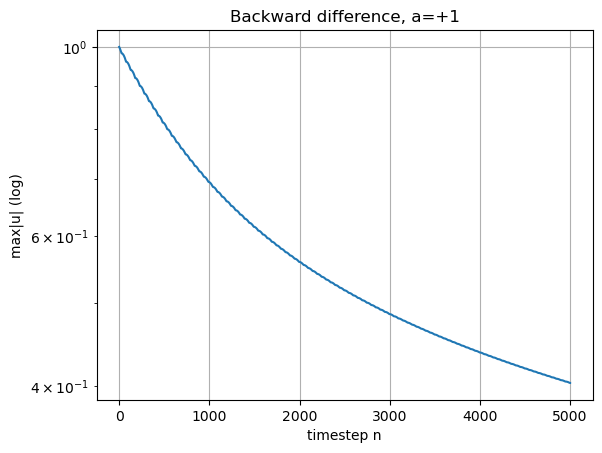

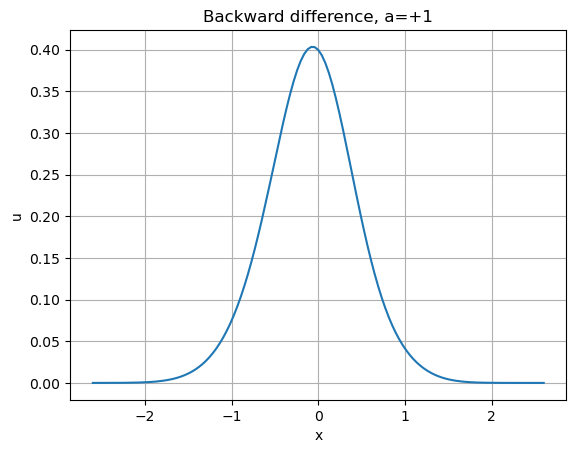

Backward difference, a=-1, onset = 17


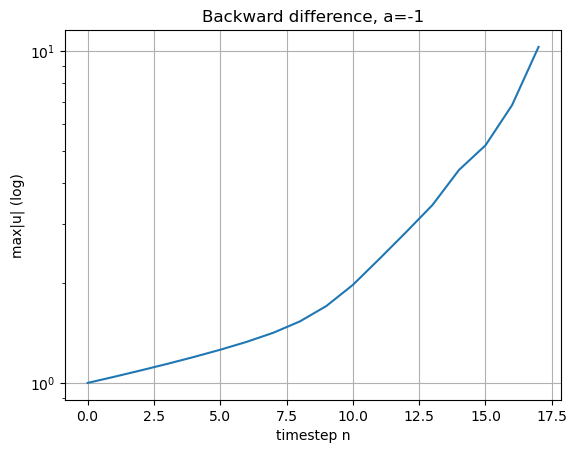

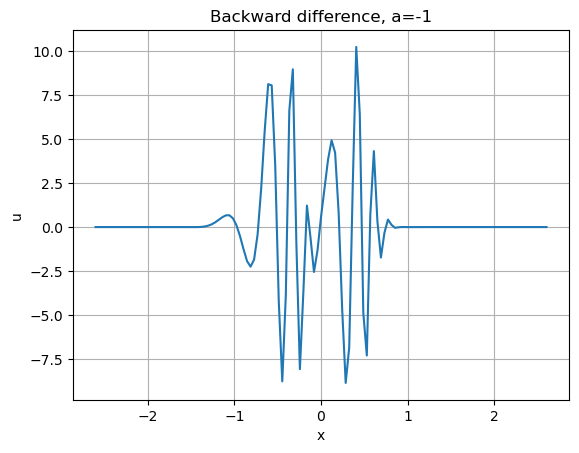

In [12]:
# In Task 1.1 we keep the same periodic grid style as in Exercise 2b,
# while in the later parts we use ghost cells for convenience.
#Part 1
# Task 1.1
# We repeat the numerical simulation from Exercise 2b, but now with a = +1 (instead of a = -1) 
# We recall the FTFS, if we have the constant a > 0. this method will be changed to Downwind, the error increases. 
# Define the intial value
x0= -2.6
xf = 2.6
a = +1.0
cfl =0.98
TH_FACTOR = 3.0
max_steps = 5000


# initial condition
def u0(x):
    
    return torch.cos(6*torch.pi*x/5)**2 / torch.cosh(5*x**2)

def the_periodic(u):
    u[0] = u[-2]
    u[-1] = u[1]
    return u
# Consider that the FTFS and periodic and count which step it blows up at
def run_and_count(N):
    dx = (xf - x0) / N
    dt = cfl * dx / abs(a)

    # grid, N intervals,we have N+1 points
    x = torch.linspace(x0, xf, N+1, device=device, dtype=dtype)

    # initial condition + periodic
    u = u0(x)
    u[-1] = u[0]

    M0 = torch.max(torch.abs(u)).item()
    TH = TH_FACTOR * M0

    max_hist = [M0]
    onset = None

    for n in range(1, max_steps + 1):
        u_new = u.clone()

        # FTFS update
        u_new[:-1] = u[:-1] - a * (u[1:] - u[:-1]) * (dt / dx)

        # periodic
        u_new[-1] = u_new[0]

        u = u_new

        Mn = torch.max(torch.abs(u)).item()
        max_hist.append(Mn)

        # How many steps we can get that 
        if (Mn > TH) or torch.isnan(u).any() or torch.isinf(u).any():
            onset = n
            break

    return onset, x, u, max_hist

# Define the intervals

for N in [128, 1024]:
    onset, x, u_end, max_hist = run_and_count(N)
    print(f"N={N} (points={N+1}), instability step = {onset}")

    plt.figure()
    plt.plot(max_hist)
    plt.yscale("log")
    plt.xlabel("timestep n")
    plt.ylabel("max|u| (log)")
    plt.title(f"max|u|, N={N}, onset={onset}")
    plt.grid(True)

    plt.figure()
    plt.plot(x.detach().cpu().numpy(), u_end.detach().cpu().numpy())
    plt.xlabel("x")
    plt.ylabel("u")
    plt.title(f"u(x) when stopped, N={N}")
    plt.grid(True)

plt.show()


# Part 1.2
# Use backward finite differences from nm_lib

def run_backward_lib(N, a=1.0, cfl_cut=0.98, TH=10.0, max_steps=5000):
    dx = (xf - x0) / N
    dt = cfl_cut * dx / abs(a)

    x_phys = torch.linspace(x0, xf, N+1, device=device, dtype=dtype)

    u = torch.empty(N+3, device=device, dtype=dtype)
    u[1:-1] = u0(x_phys)
    u = the_periodic(u)

    max_hist = [torch.max(torch.abs(u[1:-1])).item()]
    onset = None

    for n in range(1, max_steps + 1):
        dudx = lib_ddx_torch(nm3.deriv_bck, u, dx)

        u[1:-1] = u[1:-1] - a * dt * dudx[1:-1]
        u = the_periodic(u)

        Mn = torch.max(torch.abs(u[1:-1])).item()
        max_hist.append(Mn)

        if (Mn > TH) or torch.isnan(u).any() or torch.isinf(u).any():
            onset = n
            break

    return onset, x_phys, u[1:-1], max_hist
"""
# Task 1.2
# In this Task, we consider the a = 1, this means that  we need use the backward, because we need move to the right side.

# We consider the backward difference, this means that 
# u_x = (u_n-u_n-1)/delta(x)
#u_i^n+1 =u_i^n -a delta t / delta x ((u_n-u_n-1) )
# Define the function. 
def backward_derivative(u,dx):
    du = torch.zeros_like(u)
    N = u.numel()-1
    for i in range(1, N):
        du[i] = (u[i] - u[i-1]) / dx

    # periodic boundary，i=0 uses i-1 = N-1
    du[0] = (u[0] - u[N-1]) / dx
    return du

def evolv_adv_burgers_bck(u, dx, nsteps, a=1.0, cfl=0.98):
    dt = cfl * dx / abs(a)
    N = u.numel()-1
    u_now = u.clone()

    for _ in range(nsteps):
        dudx = backward_derivative(u_now, dx)
        u_now = u_now - a * dt * dudx
           
    return u_now
"""
# a = +1 : should be stable for CFL <= 1
onset, x_phys, u_end, max_hist = run_backward_lib(N=128, a=1.0, cfl_cut=0.98)
print(f"Backward difference, a=+1, onset = {onset}")

plt.figure()
plt.plot(max_hist)
plt.yscale("log")
plt.xlabel("timestep n")
plt.ylabel("max|u| (log)")
plt.title("Backward difference, a=+1")
plt.grid(True)

plt.figure()
plt.plot(x_phys.detach().cpu().numpy(), u_end.detach().cpu().numpy())
plt.xlabel("x")
plt.ylabel("u")
plt.title("Backward difference, a=+1")
plt.grid(True)

plt.show()


# a = -1 : backward becomes downwind, should be unstable
onset, x_phys, u_end, max_hist = run_backward_lib(N=128, a=-1.0, cfl_cut=0.98)
print(f"Backward difference, a=-1, onset = {onset}")

plt.figure()
plt.plot(max_hist)
plt.yscale("log")
plt.xlabel("timestep n")
plt.ylabel("max|u| (log)")
plt.title("Backward difference, a=-1")
plt.grid(True)

plt.figure()
plt.plot(x_phys.detach().cpu().numpy(), u_end.detach().cpu().numpy())
plt.xlabel("x")
plt.ylabel("u")
plt.title("Backward difference, a=-1")
plt.grid(True)

plt.show()


---

## Part 2: Centered Differences

### Task 2.1: Implement Centered Differences

Use **centered finite differences** for the spatial derivative:

$$\left(\frac{\partial u}{\partial x}\right)_{x=x_i} \rightarrow \frac{u_{i+1}-u_{i-1}}{2\Delta x}   \tag{2}$$

If not already done, fill in the function `deriv_cent` in [`nm_lib`](https://github.com/AST-Course/nm_lib/tree/master/nm_lib/nm_ex/nm_lib_ex_1.py). Use the `lambda` function `ddx` and select proper limits for `bnd_limits`. Set `cfl_cut = 0.3`.

**Questions:**
1. Is any instability apparent with centered differences?
2. Does the situation change when you change the sign of $a$?

> **Note on Boundary Conditions:** Define `xx` so that:
> - The endpoint $x = x_0$ coincides with `xx[1]` (second element)
> - The endpoint $x = x_f$ coincides with `xx[nump-1]` (last element)
> 
> For the boundary condition on array `uun` at time $t + \Delta t$:
> ```python
> uun[0] = uun[nump-2]
> uun[nump-1] = uun[1]
> ```

Centered difference, a=+1.0, onset = 292
Centered difference, a=-1.0, onset = 292


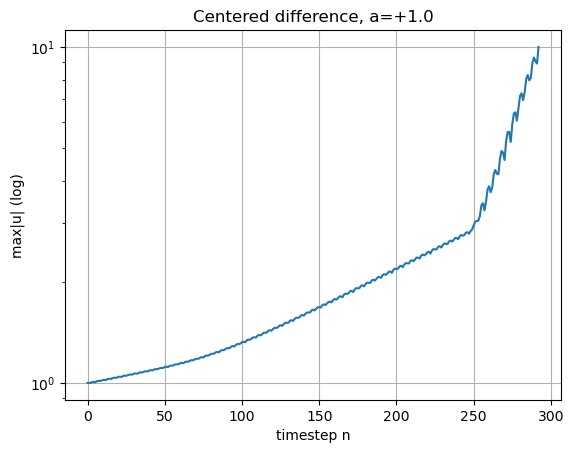

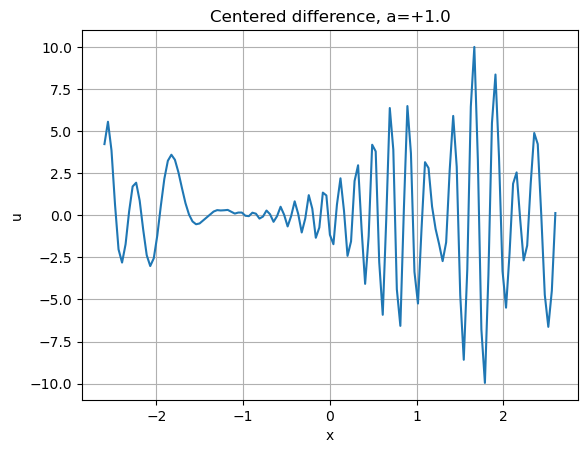

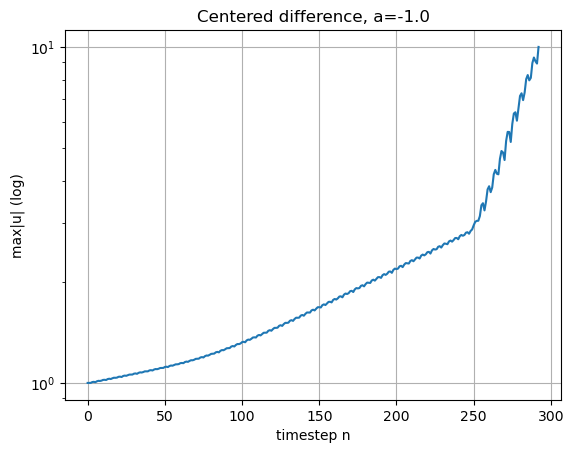

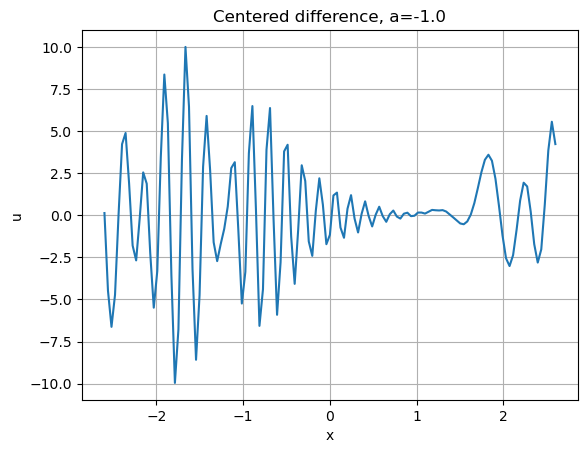

In [13]:
# Part 2
# Centered differences from nm_lib

def run_centered_lib(N, a=1.0, cfl_cut=0.3, TH=10.0, max_steps=2000):
    dx = (xf - x0) / N
    dt = cfl_cut * dx / abs(a)

    x_phys = torch.linspace(x0, xf, N+1, device=device, dtype=dtype)

    u = torch.empty(N+3, device=device, dtype=dtype)
    u[1:-1] = u0(x_phys)
    u = the_periodic(u)

    max_hist = [torch.max(torch.abs(u[1:-1])).item()]
    onset = None

    for n in range(1, max_steps + 1):
        dudx = lib_ddx_torch(nm3.deriv_cent, u, dx)

        u[1:-1] = u[1:-1] - a * dt * dudx[1:-1]
        u = the_periodic(u)
        # u[1:-1] are the physical points, while u[0] and u[-1] are ghost cells.
        Mn = torch.max(torch.abs(u[1:-1])).item()
        max_hist.append(Mn)

        if (Mn > TH) or torch.isnan(u).any() or torch.isinf(u).any():
            onset = n
            break

    return onset, x_phys, u[1:-1], max_hist



for a_val in [1.0, -1.0]:
    onset, x_phys, u_end, max_hist = run_centered_lib(N=128, a=a_val, cfl_cut=0.3)
    print(f"Centered difference, a={a_val:+.1f}, onset = {onset}")

    plt.figure()
    plt.plot(max_hist)
    plt.yscale("log")
    plt.xlabel("timestep n")
    plt.ylabel("max|u| (log)")
    plt.title(f"Centered difference, a={a_val:+.1f}")
    plt.grid(True)

    plt.figure()
    plt.plot(x_phys.detach().cpu().numpy(), u_end.detach().cpu().numpy())
    plt.xlabel("x")
    plt.ylabel("u")
    plt.title(f"Centered difference, a={a_val:+.1f}")
    plt.grid(True)

plt.show()

---

## Part 3: Stability of Non-Centered Schemes

### The CFL Condition

In the previous exercises, we saw that for $a > 0$, a **backward-oriented** finite-difference scheme yields stability. However, we used a specific value $\Delta t = 0.98 \, \Delta x / |a|$. 

**Question:** Can $\Delta t$ be chosen arbitrarily large?



### Task 3.1: Investigate the CFL Threshold

Run the program with different values of `cfl_cut`:


| Test | $\Delta t$ | `cfl_cut` |
|------|-----------|-----------|
| 1 | $0.5 \, \Delta x / a$ | 0.5 |
| 2 | $0.99 \, \Delta x / a$ | 0.99 |
| 3 | $1.01 \, \Delta x / a$ | 1.01 |
| 4 | $2.0 \, \Delta x / a$ | 2.0 |

**Questions:**
1. Do these values maintain good stability properties?
2. Does there appear to be a **threshold** in $\Delta t$ for instability?

cfl_cut= 0.5, onset(step)=None
cfl_cut=0.99, onset(step)=None
cfl_cut=1.01, onset(step)=1300
cfl_cut= 2.0, onset(step)=17


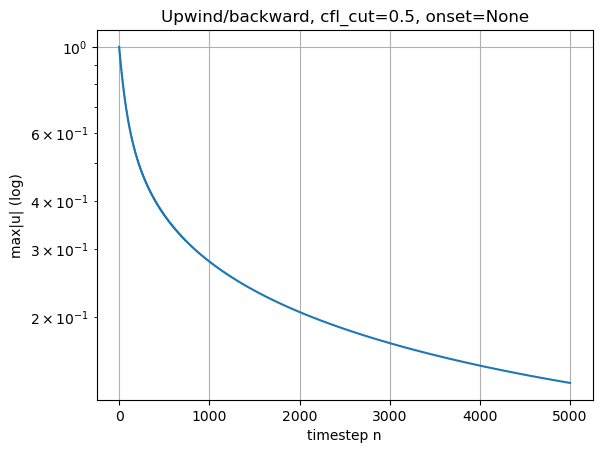

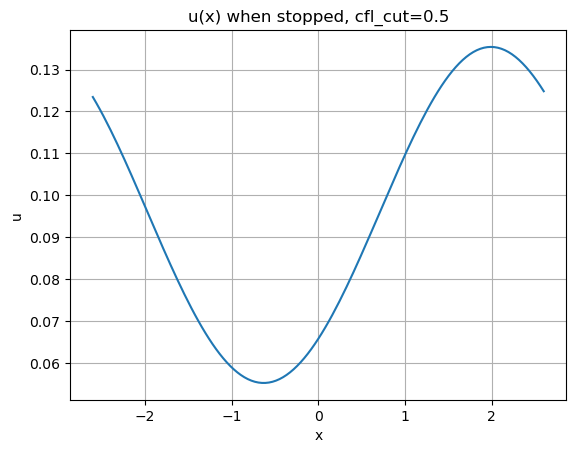

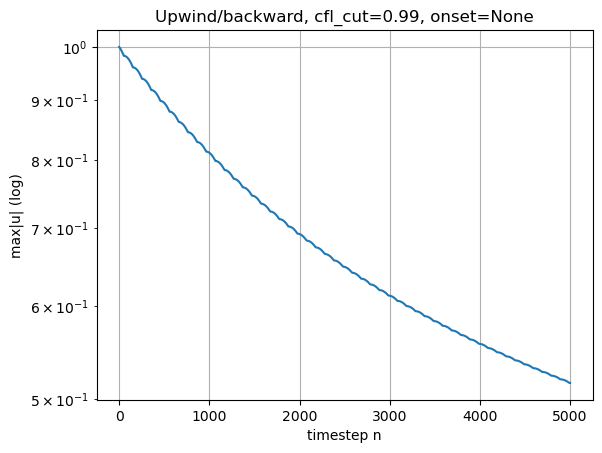

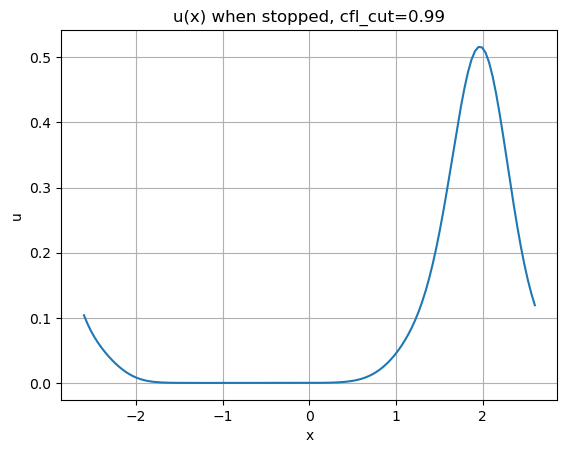

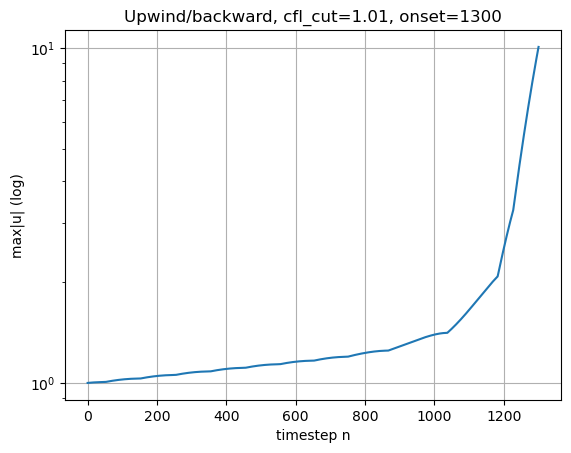

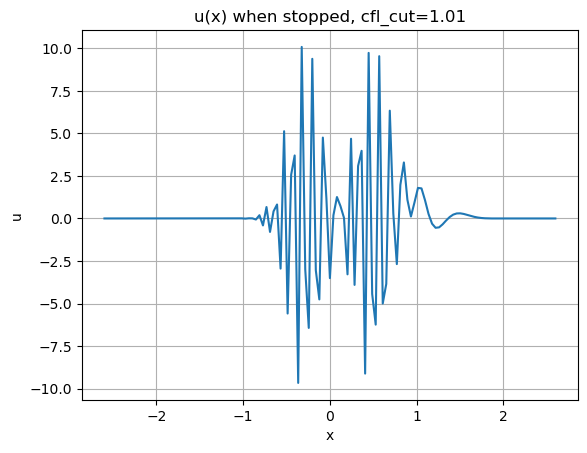

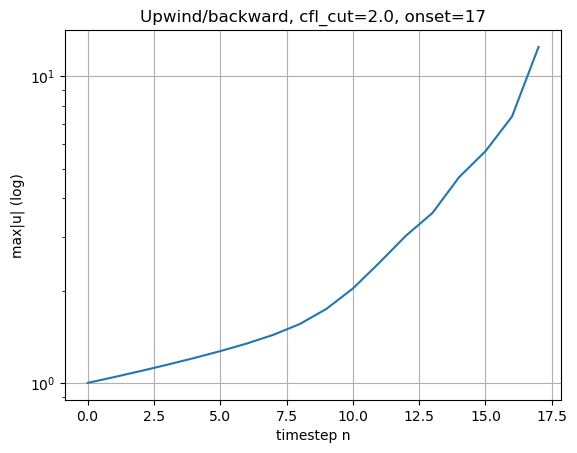

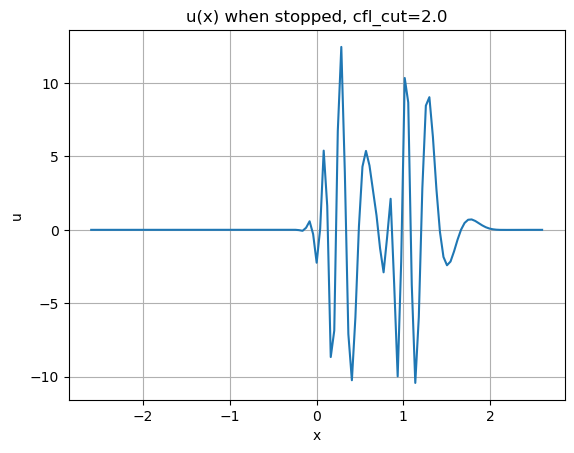

In [14]:
# Centered differences show oscillatory / unstable behavior.
# Changing the sign of a mainly changes the propagation direction,
# but does not remove the instability of the centered explicit scheme.

# Part 3  Stability of Non-Centered Schemes

# Part 3
# CFL threshold with backward (upwind) derivative from nm_lib

def run_upwind_and_count(N, cfl_cut, a=1.0, TH=10.0, max_steps=5000):
    dx = (xf - x0) / N
    dt = cfl_cut * dx / abs(a)

    x_phys = torch.linspace(x0, xf, N+1, device=device, dtype=dtype)

    u = torch.empty(N+3, device=device, dtype=dtype)
    u[1:-1] = u0(x_phys)
    u = the_periodic(u)

    max_hist = [torch.max(torch.abs(u[1:-1])).item()]
    onset = None

    for n in range(1, max_steps + 1):
        dudx = lib_ddx_torch(nm3.deriv_bck, u, dx)

        u[1:-1] = u[1:-1] - a * dt * dudx[1:-1]
        u = the_periodic(u)

        Mn = torch.max(torch.abs(u[1:-1])).item()
        max_hist.append(Mn)

        if (Mn > TH) or torch.isnan(u).any() or torch.isinf(u).any():
            onset = n
            break

    return onset, x_phys, u[1:-1], max_hist

"""
# Task 3.1
# Investigate the CFL Threshold

# In this problem, the aim is to test different dt and run this
# to see when it blows up.
# Since when a > 0, this is an explicit upwind scheme,
# the stability condition is the classical CFL.
# Hence cfl_cut = 1.

def the_periodic(u):
    u[0]  = u[-2]
    u[-1] = u[1]
    return u

def backward_derivative(u, dx):
    du = torch.zeros_like(u)
    du[1:-1] = (u[1:-1] - u[:-2]) / dx
    return du

def run_upwind_and_count(N, cfl_cut, a=1.0, TH=10.0, max_steps=5000):
    dx = (xf - x0) / N
    dt = cfl_cut * dx / abs(a)

    x_phys = torch.linspace(x0, xf, N+1, device=device, dtype=dtype)

    # u with  points
    u = torch.empty(N+3, device=device, dtype=dtype)
    u[1:-1] = u0(x_phys)
    u = the_periodic(u)

    max_hist = [torch.max(torch.abs(u[1:-1])).item()]
    onset = None

    for n in range(1, max_steps + 1):
        dudx = backward_derivative(u, dx)

        # update physical points
        u[1:-1] = u[1:-1] - a * dt * dudx[1:-1]
        u = the_periodic(u)

        Mn = torch.max(torch.abs(u[1:-1])).item()
        max_hist.append(Mn)

        # fixed blow-up rule
        if (Mn > TH) or torch.isnan(u).any() or torch.isinf(u).any():
            onset = n
            break

    return onset, x_phys, u[1:-1], max_hist
#Plot
for cfl_cut in [0.5, 0.99, 1.01, 2.0,3.0,4.0]: #Choose the value

    onset, x_phys, u_end, max_hist = run_upwind_and_count(N=128, cfl_cut=cfl_cut, a=1.0)
    print(f"cfl_cut={cfl_cut:>4}  onset(step)={onset}")

    plt.figure()
    plt.plot(max_hist)
    plt.yscale("log")
    plt.xlabel("timestep n")
    plt.ylabel("max|u| (log)")
    plt.title(f"Upwind/backward, cfl_cut={cfl_cut}, onset={onset}")
    plt.grid(True)

    plt.figure()
    plt.plot(x_phys.detach().cpu().numpy(), u_end.detach().cpu().numpy())
    plt.xlabel("x"); plt.ylabel("u")
    plt.title(f"u(x) when stopped, cfl_cut={cfl_cut}")
    plt.grid(True)

plt.show()
"""

for cfl_cut in [0.5, 0.99, 1.01, 2.0]:
    onset, x_phys, u_end, max_hist = run_upwind_and_count(N=128, cfl_cut=cfl_cut, a=1.0)
    print(f"cfl_cut={cfl_cut:>4}, onset(step)={onset}")

    plt.figure()
    plt.plot(max_hist)
    plt.yscale("log")
    plt.xlabel("timestep n")
    plt.ylabel("max|u| (log)")
    plt.title(f"Upwind/backward, cfl_cut={cfl_cut}, onset={onset}")
    plt.grid(True)

    plt.figure()
    plt.plot(x_phys.detach().cpu().numpy(), u_end.detach().cpu().numpy())
    plt.xlabel("x")
    plt.ylabel("u")
    plt.title(f"u(x) when stopped, cfl_cut={cfl_cut}")
    plt.grid(True)

plt.show()

# JMS 

<span style="color:green">Well done! all the mandatory if finished.</span>


---

## Part 4: Burgers' Equation (Optional)

> **Note:** Parts 4A and 4B below are independent optional extensions. You may complete either or both.

### Part 4A: The Nonlinear Advection Equation

Consider **Burgers' equation**:

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = 0   \tag{3}$$

This can be viewed as the advection equation with $a(x,t,u) = u$.

**Physical significance:** This equation describes:
- Motion of a non-accelerated fluid with arbitrary initial velocity
- Spontaneous formation of **discontinuities** (shocks)


### Discussion: Shock Formation

In the numerical solution, we see the initial condition evolving into something resembling a **discontinuity**. This happens because:

- Characteristic curves $dx_p/dt = a(x,t,u) = u$ are steeper (faster) for larger $u$
- The solution is constant along characteristics
- Faster elements catch up to slower ones ahead, causing **steepening**

**Numerical considerations:**

1. **Accuracy:** Computing large derivatives across the jump cannot be very accurate, yet the program continues without crashing

2. **Weak solutions:** When discontinuities form, one must consider **jump relations** (internal boundary conditions) across the discontinuity

3. **Open question:** Does our simple numerical scheme approximate the mathematically-exact weak solution?

> **Note:** The term $u \, \partial u/\partial x$ appears in fluid dynamics acceleration. Much of the beautiful physics in the universe is due to such nonlinearities!

---

### Part 4B: Forward Derivative and Lax Method

> **Prerequisite:** Complete [Exercise 4](https://github.com/AST-Course/AST5110/blob/main/notebooks/ex_4.ipynb) first.

### Task 4A.1: Implement Burgers' Equation

Modify your program to solve eq. (3) by setting $a(x_i, t^n) = u^n_i$.

**Setup:**
- Domain: $x \in [-1.4, 2.0]$
- Initial condition:
$$u(x,t=0) = A\left[\tanh\left(\frac{x+x_c}{W}\right)-\tanh\left(\frac{x-x_c}{W}\right) \right] + B \tag{5}$$
- Parameters: $A = 1.0$, $x_c = 0.70$, $W = 0.1$, $B = 0.3$
- Final time: $t_f = 100$

**Implementation:** Fill in functions `evolv_uadv_burgers` and `step_uadv_burgers` in [`nm_lib`](https://github.com/AST-Course/nm_lib/tree/master/nm_lib/nm_ex/nm_lib_ex_3.py).

**Questions:**
1. Explain in physical/mathematical terms the solution you observe
2. Change to $A = -0.02$ and explain the result

### Task 4B.1: Compare Methods for Burgers' Equation

Using the same setup as Part 4A, solve using:

1. **Forward spatial derivative:**
$$u^{n+1}_j = u^{n}_j - \frac{\Delta t}{\Delta x} u^{n}_j(u^{n}_j - u^{n}_{j+1})$$

2. **Lax method** (from [exercise 4](https://github.com/AST-Course/AST5110/blob/main/notebooks/ex_4.ipynb))

**Questions:**
1. What do you observe?
2. Why do you think the solution might not be correct?

> **Hint:** The issue relates to **flux conservation**. When discretizing $u \partial u/\partial x$, different formulations (e.g., $u_j (u_{j+1} - u_j)/\Delta x$ vs. $(u_{j+1}^2 - u_j^2)/(2\Delta x)$) are not equivalent at the discrete level. The latter preserves the integral of $u^2$ (energy), while the former does not. See [Staggered Mesh](https://github.com/AST-Course/AST5110/wiki/Staggered-mesh) for details on conservative formulations.

### Further Reading

See [Staggered Mesh](https://github.com/AST-Course/AST5110/wiki/Staggered-mesh) documentation on how a staggered mesh allows preserving conservation properties.

---

## Hints

<details>
<summary><b>Hint 1: Why does sign of $a$ matter?</b></summary>

The **upwind direction** matters! Information propagates in the direction of $a$:
- If $a > 0$: information comes from the left → use backward differences
- If $a < 0$: information comes from the right → use forward differences

Using the wrong direction means you're extrapolating rather than interpolating.
</details>

<details>
<summary><b>Hint 2: Recognizing instability</b></summary>

Signs of numerical instability:
- Rapid growth of oscillations (often starting small)
- Values growing without bound
- High-frequency "wiggles" appearing in the solution
- Solution blowing up to `inf` or `NaN`
</details>

<details>
<summary><b>Hint 3: The CFL condition physically</b></summary>

The CFL number $C = |a| \Delta t / \Delta x$ represents how many grid cells information travels per timestep. If $C > 1$, information "jumps over" grid points, leading to instability.
</details>


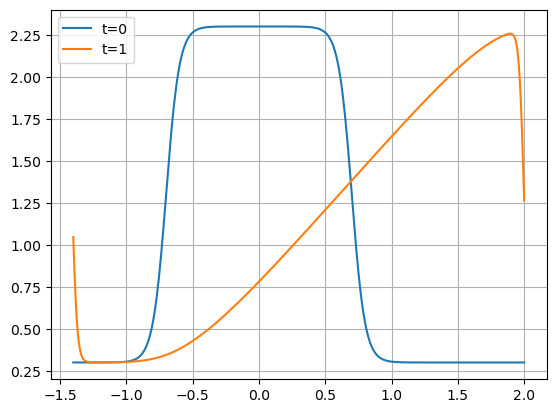

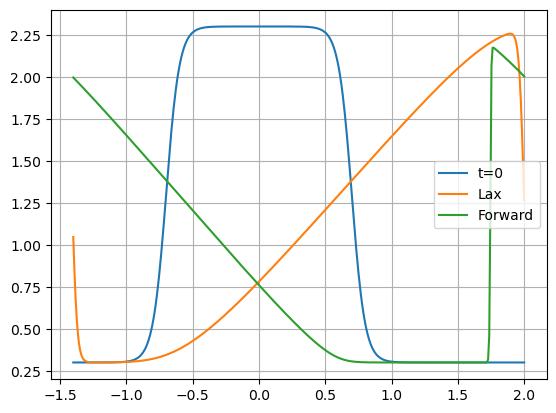

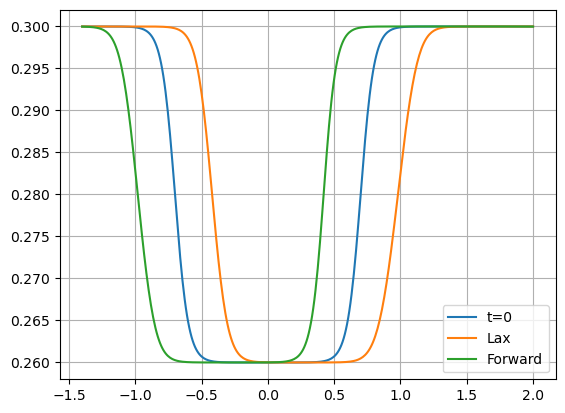

In [ ]:

#Comment

# Task 1.1

#When we change the a = -1 to a =1 , but still keep the FTFS scheme. The solution becomes unstable.
#The maximum amplitude max |u| grows rapidly. And the solution develops strong oscillations and spikes.
#For N = 128 the instability becomes clear after about 13 time steps, while for about 1024 points, 
#It appears after about 36 steps.
#Increasing N delays the onset, but the method is still unstable.


# Task 1.2

#Using the backward finite differences for the spatial derivative gives an upwind scheme when  a=+1
#And the simulation becomes stable for CFL <= 1
#If we use backward differences with a = -1
#The scheme becomes downwind and is unstable.



# The conclusion 

#We we confirmed the CFL stability limit for the explicit upwind scheme.
#It stay stable and becomes unstable for CFL > 1

#In the stable case the solution damped by numerical diffusion,
#While the downwind choice causes rapid blow up.

#About these plots.

#These plots show that when the CFL number is too large.

#The solution becomes unstable.

#max|u| grows rapidly and u(x) develops non-physical oscillations and spikes, Blows up.


#Part 4 Burgers' Equation (Optional)

# Part 4b  Forward Derivative and Lax Method
# In this problem we consider the Inviscid Burgers' Equation

# Task 4A Implement Burgers' Equation
#Define the intial condition 

def initial_burger(x,A =1.0): 
    #Parameter
    xc = 0.7
    W  = 0.1
    B  = 0.3
    return A*(torch.tanh((x+xc)/W) - torch.tanh((x-xc)/W)) + B
def the_periodic(u):
    u[0]  = u[-2]
    u[-1] = u[1]
    return u
#Consider the Lax-Method 
def step_uadv_burgers(u, dt, dx):
    u_next = torch.zeros_like(u)
    # flux f(u) = u^2/2 
    f = 0.5 * u**2
    # Lax-Friedrichs / Lax scheme
    u_next[1:-1] = 0.5*(u[2:] + u[:-2]) - (dt/(2*dx))*(f[2:] - f[:-2])
    u_next = the_periodic(u_next)
    return u_next
def evolv_uadv_burgers(N, tf=1.0, cfl_cut=0.5,A=1.0):
    # [-1.4, 2.0]
    x0, xf = -1.4, 2.0
    dx = (xf - x0) / N
    x_phys = torch.linspace(x0, xf, N+1, device=device, dtype=dtype)                                  
    u = torch.empty(N+3, device=device, dtype=dtype)
    u[1:-1] = initial_burger(x_phys,A=A)
    u = the_periodic(u)
    t = 0.0
    while t < tf:
        umax = torch.max(torch.abs(u[1:-1])).item()
        if umax < 1e-14:
            break
        dt = cfl_cut * dx / umax
        if t + dt > tf:
            dt = tf - t
        u = step_uadv_burgers(u, dt, dx)
        t += dt
    return x_phys, u[1:-1]
x, u_final = evolv_uadv_burgers(N=400, tf=1.0, cfl_cut=0.5)
plt.figure()
plt.plot(x.detach().cpu().numpy(), initial_burger(x).detach().cpu().numpy(), label="t=0")
plt.plot(x.detach().cpu().numpy(), u_final.detach().cpu().numpy(), label="t=1")
plt.grid(True); plt.legend()
plt.show()



# Task 4B Compare Methods for Burgers' Equation
# Forward Derivative Method
def step_uadv_burgers_forward(u, dt, dx):
    u_next = u.clone()
    # forward derivative version from the handout
    # u_j^{n+1} = u_j^n - (dt/dx) u_j^n (u_j^n - u_{j+1}^n)
    u_next[1:-1] = u[1:-1] - (dt / dx) * u[1:-1] * (u[1:-1] - u[2:])
    u_next = the_periodic(u_next)
    return u_next
def evolv_uadv_burgers_forward(N, tf=1.0, cfl_cut=0.5, A=1.0):
    # domain [-1.4, 2.0]
    x0, xf = -1.4, 2.0
    dx = (xf - x0) / N
    x_phys = torch.linspace(x0, xf, N+1, device=device, dtype=dtype)
    u = torch.empty(N+3, device=device, dtype=dtype)
    u[1:-1] = initial_burger(x_phys, A=A)
    u = the_periodic(u)
    t = 0.0
    while t < tf:
        umax = torch.max(torch.abs(u[1:-1])).item()
        if umax < 1e-14:
            break
        dt = cfl_cut * dx / umax
        if t + dt > tf:
            dt = tf - t
        u = step_uadv_burgers_forward(u, dt, dx)
        t += dt
    return x_phys, u[1:-1]
x = torch.linspace(-1.4, 2.0, 401, device=device, dtype=dtype)
x_lax, u_lax = evolv_uadv_burgers(N=400, tf=1.0, cfl_cut=0.5, A=1.0)
x_fwd, u_fwd = evolv_uadv_burgers_forward(N=400, tf=1.0, cfl_cut=0.5, A=1.0)
plt.figure()
plt.plot(x.detach().cpu().numpy(), initial_burger(x, A=1.0).detach().cpu().numpy(), label="t=0")
plt.plot(x_lax.detach().cpu().numpy(), u_lax.detach().cpu().numpy(), label="Lax")
plt.plot(x_fwd.detach().cpu().numpy(), u_fwd.detach().cpu().numpy(), label="Forward")
plt.grid(True)
plt.legend()
plt.show()
x_lax2, u_lax2 = evolv_uadv_burgers(N=400, tf=1.0, cfl_cut=0.5, A=-0.02)

x_fwd2, u_fwd2 = evolv_uadv_burgers_forward(N=400, tf=1.0, cfl_cut=0.5, A=-0.02)

plt.figure()
plt.plot(x.detach().cpu().numpy(), initial_burger(x, A=-0.02).detach().cpu().numpy(), label="t=0")
plt.plot(x_lax2.detach().cpu().numpy(), u_lax2.detach().cpu().numpy(), label="Lax")
plt.plot(x_fwd2.detach().cpu().numpy(), u_fwd2.detach().cpu().numpy(), label="Forward")
plt.grid(True)
plt.legend()
plt.show()

#Comment


# For Burgers' equation, the local propagation speed is a = u.
# This means that larger values of u move faster than smaller values,
# so compressive parts of the profile steepen and may develop into shock-like fronts.
#
# The Lax method is based on the conservative form
# u_t + (u^2 / 2)_x = 0,
# while the forward method discretizes u*u_x directly.
# These two formulations are equivalent in the continuous equation,
# but they are not equivalent at the discrete level once steep gradients appear.
#
# Therefore, the forward method may fail to approximate the correct weak solution,
# whereas the Lax method is more appropriate as a conservative reference method.
# On the other hand, the Lax method is diffusive, so the front is smeared numerically.
#
# When A = -0.02, the variation in u is much smaller,
# so the nonlinear steepening is weaker and the solution changes more gently.

#Figur 1
# The Burgers solution moves to the right and steepens because the local speed is u.
# Larger values travel faster, so the right edge compresses and the left edge spreads out.
# The Lax profile is smeared because of numerical diffusion.


#Figur 2

# The Lax and forward solutions differ strongly for A = 1.
# This shows that discretizing u*u_x directly is not equivalent to using the conservative flux form at the discrete level.
# The forward method may therefore fail to approximate the correct weak solution
# or produce an incorrect shock profile.


#Figur 3

# For A = -0.02, the variation in u is much smaller, so the nonlinear steepening is weaker.
# Both solutions stay closer to the initial profile, although they still do not match exactly.


# JMS 

<span style="color:red">About the optionals, I'm not sure I'm following what you are doing. Lets discuss this in the tutorial</span>